# Reliability dell'editing di concetti in VLM (**LLaVA-1.5-7B**)

Solo esperimento di **reliability**: quante volte `src` viene rimosso, quante volte `new_src` viene
nominato, quante volte lo swap `src`->`new_src` riesce pulito. Stessi 300 trial per tutti i metodi.

## Metodi
| id | metodo | meccanismo |
|---|---|---|
| **`J-taylor`** | il tuo — `J^V`+`J^T` pesati (Taylor), innesto **ortogonale** a src | attivazioni, vis+txt |
| `J-taylor-raw` | come sopra ma **senza** ortogonalizzazione (contrasto) | attivazioni, vis+txt |
| `J` | ablazione — solo `J^V` sui patch | attivazioni |
| **`JV-pinv`** | swap via **pseudo-inversa** nelle coordinate del Jacobian Lens visivo (Anthropic, *The Jacobian Lens*, 2026) | patch visivi, lente `J^V` |
| `logit` / `random` | controlli a norma appaiata | attivazioni |
| **`project_away`** | adattamento PROJECTAWAY con direzione **logit lens** | attivazioni immagine, un solo layer |
| **`pai`** | PAI, ablation conservativa **Image-Centric Logit Refine (Eq. 4)** | decoding contrastivo image/text-only |
| **`pai_targeted`** | adattamento mirato di PAI per rimuovere `src` | decoding contrastivo con ramo negativo condizionato su `src` |

## I due nuovi metodi (presi dai paper, solo la parte pertinente)

**`project_away`** — adattamento dell'Algorithm 1 di PROJECTAWAY in cui la direzione
del concetto non e' ricavata da Jacobian Lens e non e' l'hidden state testuale del paper:
si usa direttamente la direzione della **logit lens**, cioe' la riga dell'unembedding
`W_U[token_id]`. Per ogni embedding immagine `k`, si calcola `p = k . t`; se `p > 0`:
`k' = k - alpha * (p / ||t||^2) * t`, altrimenti `k` resta invariato. Nessuna reinserzione e
nessuna rinormalizzazione. Il layer immagine e l'intensita' restano quelli del paper per LLaVA:
`l^I=19`, `alpha=3.5`. Questa baseline va quindi indicata come **ProjectAway-logit**, non come
replica esatta del PROJECTAWAY originale.

**`JV-pinv`** — "patching in lens coordinates" da *The Jacobian Lens* (Anthropic,
transformer-circuits.pub, 2026): dati i J-lens vector `v_s` (src) e `v_t` (new_src) letti con la
lente **visiva** `J^V`, si formano `V=[v_s v_t]`, le coordinate `c = V+ h` (pseudo-inversa), e si
scambiano: `h_patched = h + alpha*V(swap(c) - c)`. A differenza del project-away+innesto, gestisce
correttamente il caso in cui `v_s` e `v_t` non siano ortogonali tra loro.

## PAI nel confronto di rimozione
- Si usa la componente ufficiale **Image-Centric Logit Refine (Eq. 4)** con i parametri del paper per LLaVA.
- I due rami ricevono la **stessa istruzione e la stessa history**; il ramo negativo differisce solo per
  l'assenza dell'immagine. Non vengono mai forniti `src` o `new_src` a PAI.
- Non si usa l'Eq. 3 di amplificazione dell'attenzione: nel nostro benchmark di rimozione mirata sarebbe
  una componente aggiuntiva non condivisa con le altre baseline e, nelle prove precedenti, produceva output
  degeneri. Il metodo e' quindi riportato esplicitamente come ablation Eq. 4, non come replica full PAI.
- `pai_targeted` e' una variante aggiuntiva, dichiaratamente non presente nel paper: usa la stessa immagine
  nei due rami, ma il ramo negativo contiene l'affermazione `There is a SRC in the image.`. Sottraendo tale
  distribuzione si ottiene una rimozione condizionata su `src`. Non usa mai `new_src`, quindi resta una baseline
  di sola rimozione e non compare nei grafici di target nominato o swap.
- **Solo reliability**: rimossi sweep di intensita', diagnostica Taylor standalone, distanza
  semantica, matrice di specificita'.
- **Cella finale AUTONOMA**: legge i risultati direttamente da disco (JSON), senza bisogno che il
  resto del notebook sia stato eseguito in questa sessione — nessun modello richiesto.

## Setup
- `alpha` (rimozione) fissa a 1 per i metodi a hook. 300 immagini. Lenti caricate da
  `./Corretto/jlens_llm_cache_J_Shared100/`. Notebook dentro `J`. Output in
  `./risultati_J_vs_baselines_llava_a1_ortho_JV_pinv_PAI_fair_plus_targeted_ProjectAway_logit/`. La nuova cartella impedisce di
  riutilizzare accidentalmente i risultati delle vecchie implementazioni PAI.

In [1]:
# 0.1 — Config. Il notebook vive DENTRO la cartella J.
import os, re, math, json, random, time
from contextlib import contextmanager
from io import BytesIO
from datasets import load_dataset
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ---- MODELLO ----
MODEL_NAME = "llava"               # LLaVA-1.5-7B (le lenti in cache sono di LLaVA)
MODEL_ID   = "llava-hf/llava-1.5-7b-hf"
USE_4BIT   = False                 # J-taylor richiede il backward (pesi di Taylor) -> bf16
DTYPE      = torch.bfloat16
DEVICE     = "cuda:1"

# ---- METODI A CONFRONTO (ordine = ordine nelle figure/tabelle) ----
METHODS = ["J-taylor", "J-taylor-raw", "J", "JV-pinv", "logit", "random",
           "project_away", "pai", "pai_targeted"]

# ---- lenti Jacobiane GIA' CALCOLATE (caricate, non fittate) — cache LLaVA ----
LENS_DIR   = "./Corretto/jlens_llm_cache_J_Shared100"
LENS_FILES = ["lenses_JV_paper_JT_paper.pt", "lenses.pt"]
NORM_SIGMA    = 4.0
TARGET_MODE   = "question"

# ---- dataset (COCO) ----
DATASET_ID  = "detection-datasets/coco"
SPLIT       = "val"
N_IMAGES    = 300          # solo 300 immagini
N_TASK1     = 300          # solo 300 immagini
MAX_EDITS_PER_IMG = 3

# ---- iperparametri di editing (J / logit / random / J-taylor / JV-pinv) ----
EDIT_LAYERS = [2, 6, 10, 14]       # sottoinsieme di FIT_LAYERS
EDIT_ALPHA  = 1.0                  # forza rimozione src, FISSA a 1 (J / logit / random / J-taylor)
EDIT_BETA   = 4.5                  # forza innesto new_src (J / logit / random)
MAX_NEW     = 40

# ---- Taylor (J-taylor): forze TOTALI, ripartite tra i canali dai pesi Taylor ----
WEIGHTED_ALPHA = EDIT_ALPHA        # rimozione totale ripartita vis/txt
WEIGHTED_BETA  = EDIT_BETA         # innesto totale ripartito vis/txt
TAYLOR_BATCH   = 4                 # sotto-batch per il backward dei pesi

# ---- PAI ----
# Gamma fissato al valore del paper per LLaVA; nessun tuning sui trial.
PAI_GAMMA = 1.1
# La variante targeted usa lo stesso gamma per evitare un vantaggio da tuning separato.
PAI_TARGETED_GAMMA = PAI_GAMMA

# ---- PROJECTAWAY-logit — rimozione pura con direzione logit lens ----
PA_LAYER_I = 19      # layer immagine da editare: valore del paper per LLaVA
PA_ALPHA   = 3.5     # alpha invariato rispetto al paper per LLaVA

# ---- JV-pinv (Anthropic, patching in lens coordinates via J^V sui patch visivi) ----
PINV_ALPHA = 1.0     # 1.0 = swap completo delle due coordinate

# ---- output (dentro J) — stessa cartella della run precedente: i metodi gia' calcolati vengono
#      riletti da cache (run_part1 riprende per-metodo), si calcolano solo i metodi nuovi ----
CACHE  = "./risultati_J_vs_baselines_llava_a1_ortho_JV_pinv_PAI_fair_plus_targeted_ProjectAway_logit"
os.makedirs(CACHE, exist_ok=True)
FIGDIR = os.path.join(CACHE, "figs");    os.makedirs(FIGDIR, exist_ok=True)
RESDIR = os.path.join(CACHE, "results"); os.makedirs(RESDIR, exist_ok=True)

SEED = 0
random.seed(SEED); torch.manual_seed(SEED); np.random.seed(SEED)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

PROMPT_Q = "What emotion comes through this image?"

MLABEL = {"J-taylor": "J-Taylor \u22a5 (ours)", "J-taylor-raw": "J-Taylor no-\u22a5",
          "J": "J (solo J^V)", "JV-pinv": "JV-pinv (Anthropic, J^V)", "logit": "logit lens",
          "random": "random dir", "project_away": "ProjectAway-logit (α=3.5)",
          "pai": "PAI Eq.4 (paper, no target info)",
          "pai_targeted": "PAI-targeted (src-conditioned)"}
MCOLOR = {"J-taylor": "#2E5A8F", "J-taylor-raw": "#7BA7D9", "J": "#4C72B0",
          "JV-pinv": "#55A868", "logit": "#DD8452", "random": "#8C8C8C",
          "project_away": "#B07AA1", "pai": "#C44E52", "pai_targeted": "#937860"}

def savefig(fig, name, dpi=200):
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(FIGDIR, f"{name}.{ext}"), dpi=dpi, bbox_inches="tight")
    print(f"  [fig] {os.path.join(FIGDIR, name)}.png/.pdf")

def save_json(obj, name):
    p = os.path.join(RESDIR, f"{name}.json")
    with open(p, "w") as f: json.dump(obj, f, indent=2, default=str)
    print(f"  [res] {p}"); return p

def load_json(name):
    p = os.path.join(RESDIR, f"{name}.json")
    return json.load(open(p)) if os.path.exists(p) else None

PART1 = {}

print(f"config ok | modello: {MODEL_NAME} ({MODEL_ID}) | device: {DEVICE}")
print("metodi   :", METHODS)
print("output   ->", CACHE)


/raid/users/mmarchetti/venv_jacobian/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


config ok | modello: llava (llava-hf/llava-1.5-7b-hf) | device: cuda:1
metodi   : ['J-taylor', 'J-taylor-raw', 'J', 'JV-pinv', 'logit', 'random', 'project_away', 'pai', 'pai_targeted']
output   -> ./risultati_J_vs_baselines_llava_a1_ortho_JV_pinv_PAI_fair_plus_targeted_ProjectAway_logit


In [2]:
# 0.2 — Caricamento modello LLaVA-1.5 (o Qwen2-VL), quantizzato se richiesto
from transformers import AutoProcessor

def _maybe_4bit():
    if not USE_4BIT: return None
    try:
        from transformers import BitsAndBytesConfig
        return BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                  bnb_4bit_compute_dtype=DTYPE, bnb_4bit_use_double_quant=True)
    except Exception as e:
        print("  4-bit non disponibile, uso bf16:", e); return None

qcfg = _maybe_4bit()
processor = AutoProcessor.from_pretrained(MODEL_ID)

if MODEL_NAME == "llava":
    from transformers import LlavaForConditionalGeneration as _MODEL_CLASS
else:
    try:
        from transformers import Qwen2VLForConditionalGeneration as _MODEL_CLASS
    except Exception as e:
        raise ImportError("Qwen2-VL richiede transformers>=4.45: " + str(e))

_load = dict(torch_dtype=DTYPE)
if qcfg is not None: _load.update(quantization_config=qcfg, device_map={"": DEVICE})
model = _MODEL_CLASS.from_pretrained(MODEL_ID, **_load)
if qcfg is None: model = model.to(DEVICE)
model.eval(); model.requires_grad_(False)

def _resolve_paths(model, name):
    if name == "llava":
        dec = model.model.language_model
        return dec, dec.layers, dec.norm, model.lm_head
    base = model.model
    lm = getattr(base, "language_model", base)
    layers = getattr(lm, "layers", None); norm = getattr(lm, "norm", None)
    if layers is None or norm is None:
        raise AttributeError("layers/norm del decoder non trovati")
    return lm, layers, norm, model.lm_head

decoder, LAYERS, FINAL_NORM, LM_HEAD = _resolve_paths(model, MODEL_NAME)
W_U   = LM_HEAD.weight
D_LLM = W_U.shape[1]
IMG_TOKEN = getattr(model.config, "image_token_index",
                    getattr(model.config, "image_token_id", None))
LAST = len(LAYERS) - 1
assert IMG_TOKEN is not None

tok    = processor.tokenizer
EOS_ID = tok.eos_token_id                    # usato dal decoder CFG manuale (PAI)
_ip    = processor.image_processor
_mean  = torch.tensor(getattr(_ip, "image_mean", [0.48145466, 0.4578275, 0.40821073])).view(3, 1, 1)
_std   = torch.tensor(getattr(_ip, "image_std",  [0.26862954, 0.26130258, 0.27577711])).view(3, 1, 1)
_MERGE = getattr(_ip, "merge_size", 2)

CAP = {"pixel_occlusion": MODEL_NAME == "llava",
       "fixed_visual_grid": MODEL_NAME == "llava"}

print(f"OK {MODEL_NAME} | layers: {len(LAYERS)} | d: {D_LLM} | eos: {EOS_ID} | img_token: {IMG_TOKEN}")


Loading weights: 100%|██████████| 686/686 [00:01<00:00, 519.21it/s] 


OK llava | layers: 32 | d: 4096 | eos: 2 | img_token: 32000


In [3]:
# 0.3 — Utility comuni (adattate a Gemma-3; include build_inputs_noimage per PAI e Taylor batch)
FWD_KEYS = ("input_ids", "attention_mask", "pixel_values")

def _split(o): return (o[0], o[1:]) if isinstance(o, tuple) else (o, None)
def _join(h, rest): return (h,) + tuple(rest) if rest is not None else h

class Recorder:
    """Cattura le attivazioni dei layer scelti; se `start` e' dato, il grafo parte da li'
    (necessario al backward dei pesi di Taylor)."""
    def __init__(self, layers, at, start=None):
        self.layers, self.at, self.start = layers, set(at), start
        self.acts, self.handles = {}, []
    def __enter__(self):
        idxs = self.at | ({self.start} if self.start is not None else set())
        for i in idxs:
            self.handles.append(self.layers[i].register_forward_hook(self._mk(i)))
        return self
    def _mk(self, i):
        def hook(m, inp, out):
            h, rest = _split(out)
            if i == self.start:
                h = h.detach().requires_grad_(True)
                if i in self.at: self.acts[i] = h
                return _join(h, rest)
            if i in self.at: self.acts[i] = h
            return out
        return hook
    def __exit__(self, *a):
        for x in self.handles: x.remove()

def _suffix_len(prompt, nogen, add_special):
    return max(len(tok(prompt, add_special_tokens=add_special).input_ids)
               - len(tok(nogen, add_special_tokens=add_special).input_ids), 0)

def build_inputs(image, question=None):
    """Prompt + posizioni sorgente/target + grid_hw. In Gemma-3 i token visivi sono i 256
    <image_soft_token> (IMG_TOKEN), quadrato perfetto -> griglia 16x16."""
    q = PROMPT_Q if question is None else question
    if MODEL_NAME == "gemma":
        messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": q}]}]
        prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        nogen  = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        inp = processor(text=[prompt], images=[image], return_tensors="pt").to(DEVICE)
        ids = inp["input_ids"][0]; seq = ids.shape[0]
        img_pos = torch.where(ids == IMG_TOKEN)[0]
        if len(img_pos) == 0: raise ValueError("token immagine Gemma non trovato")
        n = int(math.isqrt(len(img_pos)))
        if n * n != len(img_pos): img_pos = img_pos[:n * n]
        grid_hw = (n, n); suffix = _suffix_len(prompt, nogen, False)
    elif MODEL_NAME == "llava":
        prompt = f"USER: <image>\n{q} ASSISTANT:"; nogen = f"USER: <image>\n{q}"
        inp = processor(images=image, text=prompt, return_tensors="pt").to(DEVICE)
        ids = inp["input_ids"][0]; seq = ids.shape[0]
        img_pos = torch.where(ids == IMG_TOKEN)[0]
        n = int(math.isqrt(len(img_pos))); grid_hw = (n, n)
        suffix = _suffix_len(prompt, nogen, True)
    else:  # qwen
        msgs = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": q}]}]
        prompt = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        nogen  = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
        inp = processor(text=[prompt], images=[image], return_tensors="pt").to(DEVICE)
        ids = inp["input_ids"][0]; seq = ids.shape[0]
        img_pos = torch.where(ids == IMG_TOKEN)[0]
        thw = inp["image_grid_thw"][0].tolist(); grid_hw = (thw[1] // _MERGE, thw[2] // _MERGE)
        suffix = _suffix_len(prompt, nogen, False)
    after = int(img_pos.max()) + 1
    text_all = torch.arange(after, seq - 1, device=ids.device)
    text_q   = torch.arange(after, max(seq - 1 - suffix, after + 1), device=ids.device)
    sel = text_q if TARGET_MODE == "question" else text_all
    return {"inputs": inp, "seq": seq, "img_pos": img_pos,
            "vis_src": img_pos, "txt_src": sel, "targets": sel, "grid_hw": grid_hw}

def build_inputs_noimage(question=None):
    """Ramo negativo di PAI Eq.4: stesso prompt, immagine assente (X_V rimosso)."""
    q = PROMPT_Q if question is None else question
    if MODEL_NAME == "llava":
        prompt = f"USER: {q} ASSISTANT:"
    else:  # gemma / qwen: chat template solo testo
        msgs = [{"role": "user", "content": [{"type": "text", "text": q}]}]
        prompt = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    try:
        inp = processor(text=prompt, return_tensors="pt")
    except Exception:
        inp = tok(prompt, return_tensors="pt")
    inp = {k: v.to(DEVICE) for k, v in inp.items() if k in ("input_ids", "attention_mask")}
    inp["use_cache"] = True
    return {k: v for k, v in inp.items() if k != "use_cache"}

def fwd_inputs(meta):
    inp = meta["inputs"]; keys = ["input_ids", "attention_mask", "pixel_values"]
    for extra in ("image_grid_thw", "pixel_values_videos", "image_sizes"):
        if extra in inp: keys.append(extra)
    return {k: inp[k] for k in keys if k in inp}

def _multi_image_forward_kwargs(metas):
    """Kwargs per 1+ immagini. Griglia fissa (Gemma/LLaVA): batch via expand+cat.
    Griglia variabile (Qwen): B==1 per forward."""
    B = len(metas); inp0 = metas[0]["inputs"]
    if B == 1:
        return {**fwd_inputs(metas[0]), "use_cache": False}, int(metas[0]["seq"])
    assert len({m["seq"] for m in metas}) == 1, "batch multi-immagine richiede lunghezze uguali"
    ids = inp0["input_ids"]; am = inp0["attention_mask"]
    kw = {"input_ids": ids.expand(B, -1), "attention_mask": am.expand(B, -1), "use_cache": False,
          "pixel_values": torch.cat([m["inputs"]["pixel_values"] for m in metas], 0)}
    if "image_grid_thw" in inp0:
        kw["image_grid_thw"] = torch.cat([m["inputs"]["image_grid_thw"] for m in metas], 0)
    return kw, int(metas[0]["seq"])

def forward_rep(inputs, dim_batch):
    d = dict(input_ids=inputs["input_ids"].expand(dim_batch, -1),
             attention_mask=inputs["attention_mask"].expand(dim_batch, -1), use_cache=False)
    pv = inputs["pixel_values"]
    d["pixel_values"] = pv.expand(dim_batch, *([-1]*(pv.dim()-1))) if pv.dim() >= 4 else pv.repeat(dim_batch, 1)
    if "image_grid_thw" in inputs:
        d["image_grid_thw"] = inputs["image_grid_thw"].repeat(dim_batch, 1)
    return d

def disp_image(meta):
    pv = meta["inputs"]["pixel_values"][0].detach().float().cpu()
    return (pv * _std + _mean).clamp(0, 1).permute(1, 2, 0).numpy()

def concept_id(word):
    for cand in (word, " " + word, word.capitalize(), " " + word.capitalize()):
        ids = tok.encode(cand, add_special_tokens=False)
        if len(ids) == 1: return ids[0]
    return None

def concept_form(word):
    for cand in (word, " " + word, word.capitalize(), " " + word.capitalize()):
        ids = tok.encode(cand, add_special_tokens=False)
        if len(ids) == 1: return ids[0], cand
    return None, None

def torch_load_any(path):
    try: return torch.load(path, map_location="cpu")
    except Exception: return torch.load(path, map_location="cpu", weights_only=False)

print("utils ok")


utils ok


In [4]:
# 0.4 — CARICAMENTO delle lenti Jacobiane J^V e J^T (nessun fit)
LENS_PATH = next((os.path.join(LENS_DIR, f) for f in LENS_FILES
                  if os.path.exists(os.path.join(LENS_DIR, f))), None)
assert LENS_PATH is not None, (
    f"Nessuna lente trovata in {LENS_DIR} tra {LENS_FILES}.\n"
    f"Il notebook deve stare DENTRO la cartella J (cwd attuale: {os.getcwd()}).")
blob = torch_load_any(LENS_PATH)
if "JV" not in blob or "JT" not in blob:
    raise KeyError(f"Il file non contiene 'JV'/'JT'. Chiavi: {list(blob.keys())}")
JV, JT = blob["JV"], blob["JT"]
print(f"lenti caricate da {LENS_PATH}")
print("  JV_mode:", blob.get("JV_mode"), "| JT_mode:", blob.get("JT_mode"),
      "| layer:", sorted(int(l) for l in JV))

JV_d = {int(l): JV[l].to(DEVICE).float() for l in JV}
JT_d = {int(l): JT[l].to(DEVICE).float() for l in JT}
FIT_LAYERS    = sorted(JV_d.keys())
SOURCE_LAYERS = list(FIT_LAYERS)                 # coerente con il file caricato
_dl = next(iter(JV_d.values())).shape
assert _dl[0] == _dl[1] == D_LLM, f"lente {tuple(_dl)} incompatibile con d={D_LLM}"
# alcuni layer dell'edit potrebbero non essere nel file: restringi in modo pulito
EDIT_LAYERS = [l for l in EDIT_LAYERS if l in FIT_LAYERS]
assert EDIT_LAYERS, "nessuno dei layer di edit e' presente nelle lenti caricate"
print("lenti ai layer:", FIT_LAYERS, "| d:", D_LLM, "| EDIT_LAYERS:", EDIT_LAYERS)


lenti caricate da ./Corretto/jlens_llm_cache_J_Shared100/lenses.pt
  JV_mode: None | JT_mode: None | layer: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
lenti ai layer: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30] | d: 4096 | EDIT_LAYERS: [2, 6, 10, 14]


In [5]:
# 0.5 — Direzioni-concetto, hook di editing per-campione, pesi Taylor visivo/testuale, generate
from functools import lru_cache
import builtins
_dict = builtins.dict     # alias sicuro: se "dict" viene sovrascritto altrove nel notebook
                          # (es. per errore in una cella di debug), qui restiamo comunque
                          # legati al builtin vero, ed evitiamo il TypeError a valle.
EPS = 1e-8

def concept_vec(layer, word, lens="V"):
    cid = concept_id(word)
    if cid is None: raise ValueError(f"'{word}' non e' single-token")
    if lens == "logit": return W_U[cid].float()
    if lens not in ("V", "T"): raise ValueError(lens)
    J = JV_d[layer] if lens == "V" else JT_d[layer]
    return W_U[cid].float() @ J

concept_vec_cached = lru_cache(maxsize=None)(concept_vec)

def _match_norm(v, ref):
    return v * (ref.norm() / v.norm().clamp_min(EPS))

def random_vec(layer, word, ref_lens="V"):
    g = torch.Generator(device="cpu").manual_seed(hash((layer, word, SEED)) % (2**31))
    v = torch.randn(D_LLM, generator=g).to(DEVICE).float()
    return _match_norm(v, concept_vec(layer, word, ref_lens))

def direction(layer, word, kind):
    """kind in {'J','logit','random'} -> vettore concetto, tutti alla stessa norma di J^V."""
    if kind == "J":      return concept_vec(layer, word, "V")
    if kind == "logit":  return _match_norm(concept_vec(layer, word, "logit"),
                                            concept_vec(layer, word, "V"))
    if kind == "random": return random_vec(layer, word)
    raise ValueError(kind)

# --- Edit PER-CAMPIONE (project-away + innesto). Con orthogonalize=True (default) il concetto da
#     INNESTARE viene prima reso ortogonale a quello RIMOSSO: cioe' si inietta solo la componente
#     di new_src ORTOGONALE a src (es. 'gatto' meno la sua parte lungo 'cane'), per non
#     reintrodurre il concetto appena tolto. orthogonalize=False -> inietta new_src intero (raw). ---
#   alpha/beta sono tensori (B,): forza per-campione (permette i pesi di Taylor per immagine).
def _mk_ps_edit_hook(idx, t_vec, new_t_vec, alpha_b, beta_b, orthogonalize=True, keep_norm=True):
    idx = idx.clone(); max_needed = int(idx.max().item()) + 1
    tn2   = (t_vec @ t_vec).clamp_min(EPS); t_hat = t_vec / tn2.sqrt()
    if new_t_vec is None:
        inj_vec, inj_n2 = None, None
    else:
        inj_vec = (new_t_vec - (new_t_vec @ t_hat) * t_hat) if orthogonalize else new_t_vec
        inj_n2  = (inj_vec @ inj_vec).clamp_min(EPS)
    a = alpha_b.view(-1, 1, 1)
    b = None if new_t_vec is None else beta_b.view(-1, 1, 1)
    def hook(m, inp, out):
        h, rest = _split(out)
        if h.shape[1] < max_needed: return out          # step di decoding -> nessun edit
        h = h.clone(); sub = h[:, idx, :].float()        # (B, P, d)
        n0   = sub.norm(dim=-1, keepdim=True)
        p    = sub @ t_vec; mask = (p > 0).float().unsqueeze(-1); pc = p.unsqueeze(-1)
        sub  = sub - mask * (a * (pc / tn2) * t_vec)     # rimozione (project-away, gated)
        if inj_vec is not None:
            sub = sub + mask * (b * (pc / inj_n2) * inj_vec)   # innesto lungo t_new ort. a t_src
        if keep_norm:
            sub = sub * (n0 / sub.norm(dim=-1, keepdim=True).clamp_min(EPS))
        h[:, idx, :] = sub.to(h.dtype)
        return _join(h, rest)
    return hook

def _ps_edit_hook(idx, spec):
    return _mk_ps_edit_hook(idx, spec["t_vec"], spec.get("new_t_vec"),
                            spec["alpha"], spec["beta"],
                            orthogonalize=spec.get("orthogonalize", True),
                            keep_norm=spec.get("keep_norm", True))

_HOOKS = {"ps_edit": _ps_edit_hook}

def _pos_map(pos): return pos if isinstance(pos, dict) else {"vis": pos}

def register_steer(specs, pos):
    pm = _pos_map(pos); handles = []
    for s in (specs or []):
        idx = pm.get(s.get("where", "vis"))
        if idx is None or len(idx) == 0: continue
        handles.append(LAYERS[s["layer"]].register_forward_hook(_HOOKS[s["kind"]](idx, s)))
    return handles

@contextmanager
def steering(specs, pos):
    handles = register_steer(specs, pos)
    try: yield
    finally:
        for h in handles: h.remove()

def _sb(x, device):
    """scalare/float -> tensore (1,) sul device (alpha/beta per B=1)."""
    return x if torch.is_tensor(x) else torch.tensor([float(x)], device=device)

def build_specs(layers, src, new_src=None, *, kind="J", alpha=EDIT_ALPHA, beta=EDIT_BETA):
    """Edit VISIVO a canale singolo per J / logit / random (hook per-campione, B=1)."""
    specs = []
    for l in sorted(layers):
        t  = direction(l, src, kind)
        nt = None if new_src is None else direction(l, new_src, kind)
        specs.append(_dict(kind="ps_edit", layer=l, where="vis", t_vec=t, new_t_vec=nt,
                           alpha=_sb(alpha, DEVICE), beta=_sb(beta, DEVICE)))
    return specs

# =====================================================================================
#  IMPORTANZA VISIVO/TESTUALE VIA TAYLOR  (usata da J-taylor e dalla Parte 3)
# =====================================================================================
def _taylor_weights_from_metas(metas, src, layers, chunk=None):
    """Pesi online (Taylor) per-campione e PER-LAYER dei due canali. Per ogni immagine e layer stima
    quanto un project-away di `src` farebbe scendere log p(src) al primo token di risposta, se
    applicato ai PATCH (J^V) o ai TOKEN (J^T) di quel layer, e normalizza i due canali dentro il
    layer -> w_v[l] + w_t[l] = 1. L'importanza di canale e' la MEDIA sulle posizioni attive (non la
    somma), cosi' visivo (molti patch) e testuale (pochi token) sono comparabili in scala.
    Ritorna {layer: (w_v, w_t)} con w_* tensori (N,) su DEVICE."""
    layers = sorted(layers); start = min(layers); chunk = chunk or TAYLOR_BATCH
    vis, txt = metas[0]["vis_src"], metas[0]["txt_src"]
    cid = concept_id(src)
    vV = {l: concept_vec_cached(l, src, "V") for l in layers}
    vT = {l: concept_vec_cached(l, src, "T") for l in layers}
    Iv = {l: [] for l in layers}; It = {l: [] for l in layers}
    for s in range(0, len(metas), chunk):
        grp = metas[s:s+chunk]
        kw, _ = _multi_image_forward_kwargs(grp)
        with Recorder(LAYERS, at=layers, start=start) as rec, torch.enable_grad():
            out = model(**kw)
            logp = out.logits[:, -1].float().log_softmax(-1)
            loss = logp[:, cid].sum()
            Hs = [rec.acts[l] for l in layers]
            grads = torch.autograd.grad(loss, Hs)
        for l, H, G in zip(layers, Hs, grads):
            H = H.detach()
            for pos, vv, bucket in ((vis, vV[l], Iv), (txt, vT[l], It)):
                h = H[:, pos, :].float(); g = G[:, pos, :].float()
                p = h @ vv; gdotv = g @ vv; vn2 = (vv @ vv).clamp_min(EPS)
                # effetto (Taylor 1o ordine) del project-away, per posizione, gated dove src e' presente
                mask = (p > 0).float()
                per_pos = mask * (p / vn2) * gdotv
                # MEDIA sulle posizioni ATTIVE, non somma: cosi' il canale visivo (576 patch) e quello
                # testuale (pochi token) sono comparabili in SCALA. La somma faceva vincere il visivo
                # per pura numerosita' -> w_vis~1 sempre (artefatto). Ora il peso riflette l'importanza
                # per-posizione reale del canale.
                num = per_pos.sum(1).clamp_min(0.0)                # (b,)
                den = mask.sum(1).clamp_min(1.0)                   # (b,) # posizioni attive del canale
                contrib = num / den
                bucket[l].append(contrib.detach())
            del H, G
        del grads, Hs, out, rec
    weights = {}
    for l in layers:
        iv = torch.cat(Iv[l]); it = torch.cat(It[l]); tot = iv + it
        wv = torch.where(tot > 0, iv / tot.clamp_min(EPS), torch.full_like(iv, 0.5))
        weights[l] = (wv, 1.0 - wv)
    return weights

def _weighted_specs(layers, src, new_src, weights, a_tot, b_tot, orthogonalize=True):
    """Spec dell'edit combinato pesato: J^V sui patch + J^T sui token, project-away/innesto identici,
    alpha/beta PER-CAMPIONE e PER-LAYER = forza_totale * peso_Taylor del canale in quel layer."""
    specs = []
    for l in sorted(layers):
        w_v, w_t = weights[l]
        specs.append(_dict(kind="ps_edit", layer=l, where="vis", orthogonalize=orthogonalize,
                           t_vec=concept_vec_cached(l, src, "V"),
                          new_t_vec=None if new_src is None else concept_vec_cached(l, new_src, "V"),
                          alpha=a_tot * w_v, beta=b_tot * w_v))
        specs.append(_dict(kind="ps_edit", layer=l, where="txt", orthogonalize=orthogonalize,
                           t_vec=concept_vec_cached(l, src, "T"),
                          new_t_vec=None if new_src is None else concept_vec_cached(l, new_src, "T"),
                          alpha=a_tot * w_t, beta=b_tot * w_t))
    return specs

@torch.no_grad()
def _apply_and_generate(image, specs, max_new, question):
    meta = build_inputs(image, question)
    with steering(specs, {"vis": meta["vis_src"], "txt": meta["txt_src"]}):
        gen = model.generate(**fwd_inputs(meta), max_new_tokens=max_new, do_sample=False)
    return tok.decode(gen[0, meta["inputs"]["input_ids"].shape[1]:], skip_special_tokens=True).strip()

def taylor_weights_single(image, src, layers, question=None):
    """Pesi Taylor {layer:(w_v,w_t)} per una singola immagine, sul prompt di generazione."""
    meta = build_inputs(image, question)
    return _taylor_weights_from_metas([meta], src, layers)

def edit_caption_taylor(image, src, new_src, layers=None, *, alpha=None, beta=None,
                        orthogonalize=True, max_new=MAX_NEW, question=None):
    """Edit combinato pesato (Taylor) su una immagine: 1) pesi per-layer  2) spec vis+txt  3) generate."""
    layers = EDIT_LAYERS if layers is None else layers
    a = WEIGHTED_ALPHA if alpha is None else alpha
    b = WEIGHTED_BETA  if beta  is None else beta
    weights = taylor_weights_single(image, src, layers, question)
    specs = _weighted_specs(layers, src, new_src, weights, a, b, orthogonalize=orthogonalize)
    return _apply_and_generate(image, specs, max_new, question)

@torch.no_grad()
def generate(image, specs=None, max_new=MAX_NEW, question=None):
    meta = build_inputs(image, question)
    with steering(specs, {"vis": meta["vis_src"], "txt": meta["txt_src"]}):
        gen = model.generate(**fwd_inputs(meta), max_new_tokens=max_new, do_sample=False)
    return tok.decode(gen[0, meta["inputs"]["input_ids"].shape[1]:], skip_special_tokens=True).strip()

# =====================================================================================
#  PROJECTAWAY-logit — rimozione con la direzione della logit lens.
#
#  Non usa JV/JT e non calcola Jacobiani. La direzione del concetto e':
#      t = W_U[token_id]
#
#  L'operatore resta quello di PROJECTAWAY:
#      k' = k - alpha * (k·t / ||t||^2) * t, se k·t > 0.
#
#  Il layer immagine l^I=19 e alpha=3.5 restano quelli del paper per LLaVA.
#  Nessuna reinserzione e nessuna rinormalizzazione.
# =====================================================================================
@lru_cache(maxsize=None)
def project_away_logit_direction(word):
    """
    Direzione logit-lens pura del concetto: riga dell'unembedding W_U.

    Non usa JV, JT, hidden state intermedi o Jacobiani.
    """
    cid = concept_id(word)
    if cid is None:
        raise ValueError(f"'{word}' non e' single-token")
    return W_U[cid].detach().float()


def _mk_project_away_hook(idx, t_vec, alpha):
    """Algorithm 1 con direzione logit lens e alpha fissato dalla configurazione."""
    idx = idx.clone()
    max_needed = int(idx.max().item()) + 1
    tn2 = (t_vec @ t_vec).clamp_min(EPS)

    def hook(m, inp, out):
        h, rest = _split(out)
        if h.shape[1] < max_needed:
            return out

        h = h.clone()
        sub = h[:, idx, :].float()

        p = (sub @ t_vec).unsqueeze(-1)
        mask = (p > 0).float()

        sub = sub - mask * (alpha * (p / tn2) * t_vec)

        h[:, idx, :] = sub.to(h.dtype)
        return _join(h, rest)

    return hook


@torch.no_grad()
def project_away_caption(image, src, *, layer_I=None, alpha=None,
                         max_new=MAX_NEW, question=None):
    """
    ProjectAway-logit: rimuove `src` dai patch visivi usando W_U[src].

    `new_src` non viene usato: e' una baseline di sola rimozione.
    """
    layer_I = PA_LAYER_I if layer_I is None else layer_I
    alpha = PA_ALPHA if alpha is None else alpha

    t_vec = project_away_logit_direction(src)
    meta = build_inputs(image, question or DESCRIBE_Q)

    handle = LAYERS[layer_I].register_forward_hook(
        _mk_project_away_hook(meta["vis_src"], t_vec, alpha)
    )
    try:
        gen = model.generate(
            **fwd_inputs(meta),
            max_new_tokens=max_new,
            do_sample=False,
        )
    finally:
        handle.remove()

    return tok.decode(
        gen[0, meta["inputs"]["input_ids"].shape[1]:],
        skip_special_tokens=True,
    ).strip()


# =====================================================================================
#  JV-pinv — swap via pseudo-inversa nelle coordinate del Jacobian Lens VISIVO (J^V).
#  (Anthropic, "The Jacobian Lens", transformer-circuits.pub 2026 — "patching in lens
#  coordinates"): V=[v_s v_t], c = V+ h, h_patched = h + alpha*V(swap(c) - c). Gestisce
#  correttamente v_s, v_t non ortogonali (a differenza del project-away+innesto).
#  Applicato ai PATCH VISIVI con i vettori della lente visiva J^V dello stesso layer.
# =====================================================================================
def _mk_pinv_swap_hook(idx, v_s, v_t, alpha):
    idx = idx.clone(); max_needed = int(idx.max().item()) + 1
    V = torch.stack([v_s, v_t], dim=1)          # (d, 2)
    Vpinv = torch.linalg.pinv(V)                # (2, d)
    def hook(m, inp, out):
        h, rest = _split(out)
        if h.shape[1] < max_needed: return out
        h = h.clone(); sub = h[:, idx, :].float()              # (B,P,d)
        c = torch.einsum("kd,bpd->bpk", Vpinv, sub)            # coordinate [c_s, c_t]
        c_swap = c.flip(-1)                                     # scambia le due coordinate
        delta = torch.einsum("dk,bpk->bpd", V, c_swap - c)     # variazione, dentro span{v_s,v_t}
        sub = sub + alpha * delta
        h[:, idx, :] = sub.to(h.dtype)
        return _join(h, rest)
    return hook

def edit_caption_jv_pinv(image, src, new_src, layers=None, *, alpha=None,
                         max_new=MAX_NEW, question=None):
    """Swap pseudo-inverso su tutti i layer di EDIT_LAYERS, sui PATCH VISIVI, usando
    le direzioni della lente VISIVA J^V specifiche del layer corrente."""
    layers = EDIT_LAYERS if layers is None else layers
    a = PINV_ALPHA if alpha is None else alpha
    q = question or DESCRIBE_Q
    meta = build_inputs(image, q)
    handles = []
    for l in sorted(layers):
        v_s = concept_vec_cached(l, src, "V")
        v_t = concept_vec_cached(l, new_src, "V")
        handles.append(LAYERS[l].register_forward_hook(_mk_pinv_swap_hook(meta["vis_src"], v_s, v_t, a)))
    try:
        with torch.no_grad():
            gen = model.generate(**fwd_inputs(meta), max_new_tokens=max_new, do_sample=False)
    finally:
        for h in handles: h.remove()
    return tok.decode(gen[0, meta["inputs"]["input_ids"].shape[1]:], skip_special_tokens=True).strip()

print("hook/steering/taylor ok")


hook/steering/taylor ok


In [6]:
# 0.6 — Loader COCO (invariato)
COCO80 = ["person","bicycle","car","motorcycle","airplane","bus","train","truck","boat","traffic light",
"fire hydrant","stop sign","parking meter","bench","bird","cat","dog","horse","sheep","cow","elephant",
"bear","zebra","giraffe","backpack","umbrella","handbag","tie","suitcase","frisbee","skis","snowboard",
"sports ball","kite","baseball bat","baseball glove","skateboard","surfboard","tennis racket","bottle",
"wine glass","cup","fork","knife","spoon","bowl","banana","apple","sandwich","orange","broccoli","carrot",
"hot dog","pizza","donut","cake","chair","couch","potted plant","bed","dining table","toilet","tv","laptop",
"mouse","remote","keyboard","cell phone","microwave","oven","toaster","sink","refrigerator","book","clock",
"vase","scissors","teddy bear","hair drier","toothbrush"]

def load_coco_full(n_images):
    ds = load_dataset(DATASET_ID, split=SPLIT, streaming=True)
    names = COCO80
    try:
        cf = ds.features["objects"].feature["category"]
        if getattr(cf, "names", None): names = cf.names
    except Exception as e:
        print("  fallback COCO80:", e)
    out = []
    for ex in ds:
        img = ex["image"].convert("RGB"); W, H = img.size
        cats = ex["objects"]["category"]; boxes = ex["objects"].get("bbox", None)
        present, area, bx = set(), {}, {}
        for j, c in enumerate(cats):
            try: nm = names[int(c)]
            except Exception: continue
            present.add(nm)
            if boxes is not None:
                b = [float(v) for v in boxes[j]]
                area[nm] = area.get(nm, 0.0) + (b[2]*b[3])/float(W*H)
                bx.setdefault(nm, []).append(b)
        if present:
            out.append(dict(image=img, present=present, area=area, boxes=bx, size=(W, H)))
        if len(out) >= n_images: break
    print(f"loaded {len(out)} COCO images; {len(names)} categorie"); return out, names

POOL_FULL, CAT_NAMES = load_coco_full(N_IMAGES)
print("immagini disponibili:", len(POOL_FULL))

  fallback COCO80: 'dict' object has no attribute 'feature'
loaded 300 COCO images; 80 categorie
immagini disponibili: 300


In [7]:
# 0.7 — Prompt di descrizione + matching testo->categorie COCO (invariato)
DESCRIBE_Q = "List the objects you can see in this image."

SYN = {
    "tv": ["tv", "television", "monitor", "screen"],
    "couch": ["couch", "sofa"],
    "motorcycle": ["motorcycle", "motorbike", "motor bike"],
    "airplane": ["airplane", "aeroplane", "plane", "aircraft"],
    "cell phone": ["cell phone", "cellphone", "mobile phone", "smartphone", "phone"],
    "potted plant": ["potted plant", "plant", "houseplant"],
    "dining table": ["dining table", "table"],
    "hot dog": ["hot dog", "hotdog"],
    "sports ball": ["sports ball", "ball"],
    "wine glass": ["wine glass", "wineglass", "glass of wine"],
    "donut": ["donut", "doughnut"],
    "person": ["person", "people", "man", "woman", "boy", "girl", "child", "human"],
}

def _variants(cat):
    base = SYN.get(cat, [cat])
    out = set()
    for w in base:
        out.add(w); out.add(w + "s")
        if w.endswith("y"): out.add(w[:-1] + "ies")
    return out

def _norm(txt): return re.sub(r"[^a-z ]", " ", txt.lower())

def described_objects(text, present):
    t = " " + _norm(text) + " "
    hit = set()
    for cat in present:
        for v in _variants(cat):
            if f" {v} " in t: hit.add(cat); break
    return hit

def mentions(text, word):
    t = " " + _norm(text) + " "
    return any(f" {v} " in t for v in _variants(word))

SINGLE_TOKEN_CATS = [c for c in CAT_NAMES if concept_id(c) is not None]
print(f"categorie single-token utilizzabili: {len(SINGLE_TOKEN_CATS)}/{len(CAT_NAMES)}")

categorie single-token utilizzabili: 28/80


## 0.8 — Baseline PAI equa: Image-Centric Logit Refine (Eq. 4)

Questa baseline implementa la componente **Image-Centric Logit Refine** di PAI (Liu et al.,
*Paying More Attention to Image*, 2024):

`guided_logits = gamma * logits(image, instruction, history)
                 - (gamma - 1) * logits(instruction, history)`

Criteri di fairness:

- `gamma=1.1`, valore fissato nel paper per LLaVA; nessun tuning sui trial.
- Il ramo positivo e quello text-only usano la **stessa istruzione**.
- A ogni passo autoregressivo ricevono lo **stesso token generato**, quindi la history e' condivisa.
- PAI non riceve mai `src` o `new_src`: non c'e' negative prompting, target prompting o informazione
  sull'oggetto valutato.
- Decoding greedy e stesso `MAX_NEW` degli altri metodi.
- L'Eq. 3 di PAI (amplificazione delle attention verso i token immagine) non viene inclusa in questa
  baseline conservativa: e' una componente aggiuntiva non mirata alla rimozione di `src` e nelle
  prove precedenti causava output degeneri. La label riporta quindi esplicitamente **PAI Eq.4**.

PAI e' un metodo generale di mitigazione delle allucinazioni, non un concept editor mirato:
viene confrontato sulla sola metrica `src rimosso`, non su target nominato o swap.


### Variante aggiuntiva: `pai_targeted`

Per il confronto di rimozione mirata aggiungiamo una variante esplicitamente condizionata su `src`:

`guided_logits = gamma * logits(image, neutral_prompt, history)
                 - (gamma - 1) * logits(image, prompt_with_src, history)`

dove `prompt_with_src = neutral_prompt + " There is a SRC in the image."`.

Questa variante:

- usa `src`, come ProjectAway e gli altri metodi di rimozione;
- non usa `new_src`;
- usa la stessa immagine e la stessa history nei due rami;
- usa lo stesso `gamma=1.1` di PAI, senza tuning separato;
- non usa l'amplificazione delle attention;
- e' riportata come adattamento `PAI-targeted`, non come metodo originale del paper.


In [8]:
# 0.8 — PAI: Image-Centric Logit Refine (Eq. 4), implementazione conservativa e fair
@torch.no_grad()
def pai_logit_refine_decode(image, question=None, gamma=PAI_GAMMA, max_new=MAX_NEW):
    """
    PAI Eq. 4:
        guided = gamma * logits(y | X_V, X_I, X_H)
                 - (gamma - 1) * logits(y | X_I, X_H)

    Fairness:
      - stessa istruzione nei due rami;
      - stessa history autoregressiva;
      - nessun uso di src/new_src;
      - ramo negativo senza immagine;
      - greedy decoding e stesso max_new degli altri metodi.
    """
    q = DESCRIBE_Q if question is None else question

    # Stessa istruzione; differisce esclusivamente la presenza di X_V.
    pos_kw = fwd_inputs(build_inputs(image, q))
    neg_kw = build_inputs_noimage(q)

    pos_past = None
    neg_past = None
    next_tok = None
    generated = []

    for step in range(max_new):
        if step == 0:
            pos_out = model(**pos_kw, use_cache=True)
            neg_out = model(**neg_kw, use_cache=True)
        else:
            # Lo stesso token entra in entrambi i rami: X_H resta allineata.
            pos_out = model(
                input_ids=next_tok,
                past_key_values=pos_past,
                use_cache=True,
            )
            neg_out = model(
                input_ids=next_tok,
                past_key_values=neg_past,
                use_cache=True,
            )

        pos_past = pos_out.past_key_values
        neg_past = neg_out.past_key_values

        pos_logits = pos_out.logits[:, -1, :].float()
        neg_logits = neg_out.logits[:, -1, :].float()

        guided_logits = (
            gamma * pos_logits
            - (gamma - 1.0) * neg_logits
        )

        next_tok = guided_logits.argmax(dim=-1, keepdim=True)

        if int(next_tok.item()) == EOS_ID:
            break

        generated.append(int(next_tok.item()))

    return tok.decode(generated, skip_special_tokens=True).strip()


def pai_caption(image, src=None, new_src=None, *, gamma=PAI_GAMMA,
                question=None, max_new=MAX_NEW):
    """
    Wrapper compatibile con il registry.

    `src` e `new_src` sono deliberatamente ignorati: PAI non riceve
    informazioni sull'oggetto da rimuovere o sul target.
    """
    return pai_logit_refine_decode(
        image,
        question=question,
        gamma=gamma,
        max_new=max_new,
    )


print(f"PAI Eq.4 fair ok | gamma={PAI_GAMMA} | nessun accesso a src/new_src")


@torch.no_grad()
def pai_targeted_decode(image, src, question=None,
                        gamma=PAI_TARGETED_GAMMA, max_new=MAX_NEW):
    """
    Variante PAI-targeted per rimozione mirata.

    Ramo positivo:
        logits(y | image, istruzione neutra, history)

    Ramo negativo:
        logits(y | image, istruzione neutra + affermazione di src, history)

    Sottraendo il ramo negativo si penalizzano le continuazioni associate a src.
    `new_src` non viene mai usato.
    """
    q = DESCRIBE_Q if question is None else question

    pos_prompt = q
    neg_prompt = f"{q} There is a {src} in the image."

    # Stessa immagine nei due rami: differisce soltanto il condizionamento su src.
    pos_kw = fwd_inputs(build_inputs(image, pos_prompt))
    neg_kw = fwd_inputs(build_inputs(image, neg_prompt))

    pos_past = None
    neg_past = None
    next_tok = None
    generated = []

    for step in range(max_new):
        if step == 0:
            pos_out = model(**pos_kw, use_cache=True)
            neg_out = model(**neg_kw, use_cache=True)
        else:
            # Stessa history generata per entrambi i rami.
            pos_out = model(
                input_ids=next_tok,
                past_key_values=pos_past,
                use_cache=True,
            )
            neg_out = model(
                input_ids=next_tok,
                past_key_values=neg_past,
                use_cache=True,
            )

        pos_past = pos_out.past_key_values
        neg_past = neg_out.past_key_values

        pos_logits = pos_out.logits[:, -1, :].float()
        neg_logits = neg_out.logits[:, -1, :].float()

        guided_logits = (
            gamma * pos_logits
            - (gamma - 1.0) * neg_logits
        )

        next_tok = guided_logits.argmax(dim=-1, keepdim=True)

        if int(next_tok.item()) == EOS_ID:
            break

        generated.append(int(next_tok.item()))

    return tok.decode(generated, skip_special_tokens=True).strip()


def pai_targeted_caption(image, src, new_src=None, *,
                         gamma=PAI_TARGETED_GAMMA,
                         question=None, max_new=MAX_NEW):
    """
    Wrapper per il registry. `new_src` e' deliberatamente ignorato:
    PAI-targeted e' una baseline di rimozione, non di swap.
    """
    return pai_targeted_decode(
        image=image,
        src=src,
        question=question,
        gamma=gamma,
        max_new=max_new,
    )


print(
    f"PAI-targeted ok | gamma={PAI_TARGETED_GAMMA} | "
    "usa src, non usa new_src"
)


PAI Eq.4 fair ok | gamma=1.1 | nessun accesso a src/new_src
PAI-targeted ok | gamma=1.1 | usa src, non usa new_src


In [9]:
# 0.9 — Registry dei metodi: interfaccia UNICA per tutti gli esperimenti
#   edit_caption(method, image, src, new_src=None, question=None, strength=None) -> didascalia
#   strength: beta (innesto) per i metodi a hook, gamma per PAI. None = default di config.
def edit_caption(method, image, src, new_src=None, *, question=None,
                 strength=None, max_new=MAX_NEW):
    q = DESCRIBE_Q if question is None else question
    if method in ("J", "logit", "random"):
        beta = EDIT_BETA if strength is None else strength
        specs = build_specs(EDIT_LAYERS, src, new_src, kind=method, alpha=EDIT_ALPHA, beta=beta)
        return generate(image, specs=specs, max_new=max_new, question=q)
    if method in ("J-taylor", "J-taylor-raw"):
        beta = WEIGHTED_BETA if strength is None else strength
        ortho = (method == "J-taylor")            # J-taylor: inietta new_src ORTOGONALE a src.
        return edit_caption_taylor(image, src, new_src, EDIT_LAYERS, orthogonalize=ortho,
                                   alpha=WEIGHTED_ALPHA, beta=beta, max_new=max_new, question=q)
    if method == "pai":
        # PAI Eq.4: nessun accesso a src/new_src; gamma fissato dal paper salvo override esplicito.
        g = PAI_GAMMA if strength is None else strength
        return pai_caption(image, src, new_src, gamma=g, question=q, max_new=max_new)
    if method == "pai_targeted":
        # Adattamento mirato: usa src nel solo ramo negativo, non usa new_src.
        g = PAI_TARGETED_GAMMA if strength is None else strength
        return pai_targeted_caption(
            image, src, new_src,
            gamma=g,
            question=q,
            max_new=max_new,
        )
    if method == "project_away":                                # ProjectAway-logit: solo rimozione
        a = PA_ALPHA if strength is None else strength
        return project_away_caption(image, src, alpha=a, max_new=max_new, question=q)
    if method == "JV-pinv":                                      # Anthropic, patching in coordinate J^V sui patch visivi
        a = PINV_ALPHA if strength is None else strength
        return edit_caption_jv_pinv(image, src, new_src, EDIT_LAYERS, alpha=a,
                                    max_new=max_new, question=q)
    raise ValueError(method)

def base_caption(image, question=None, max_new=MAX_NEW):
    """Didascalia NON editata: identica per tutti i metodi, calcolata una volta sola."""
    return generate(image, specs=None, max_new=max_new, question=question or DESCRIBE_Q)

# --- smoke test su una immagine ---
_rec = _base = _src = None
for r in POOL_FULL[:40]:
    cap = base_caption(r["image"])
    hits = sorted(h for h in described_objects(cap, r["present"]) if h in SINGLE_TOKEN_CATS)
    if hits:
        _rec, _base, _src = r, cap, hits[0]; break
assert _rec is not None, "nessuna immagine con oggetto single-token citato nei primi 40 campioni"
_new = next(c for c in SINGLE_TOKEN_CATS if c not in _rec["present"])
print(f"src='{_src}'  ->  new_src='{_new}'")
print(f"{'BASE':<16}: {_base}")
for m in METHODS:
    t0 = time.time()
    print(f"{MLABEL[m]:<16}: {edit_caption(m, _rec['image'], _src, _new)}   [{time.time()-t0:.1f}s]")


src='chair'  ->  new_src='car'
BASE            : In the image, you can see a dining table, chairs, a refrigerator, a television, a clock, a potted plant, and a vase. The dining
J-Taylor ⊥ (ours): In the image, you can see a living room with a TV, a dining room table, a refrigerator, a clock, a potted plant, and a vase. There   [1.8s]
J-Taylor no-⊥   : In the image, you can see a car, a clock, a television, a refrigerator, a potted plant, a vase, a person, and a window.   [1.6s]
J (solo J^V)    : In the image, you can see a living room with a TV, a dining room table, a refrigerator, a clock, a potted plant, and a vase. There   [1.3s]
JV-pinv (Anthropic, J^V): In the image, you can see a dining table, chairs, a refrigerator, a clock, a TV, a potted plant, and a vase. The dining   [1.3s]
logit lens      : In the image, you can see a dining table, chairs, a refrigerator, a television, a clock, a potted plant, and a vase. The dining   [1.3s]
random dir      : In the image, you can see a din

# Parte 1 — Errori indotti (hallucination editing), tutti i metodi

**Ricetta** (identica al notebook originale, applicata a ogni metodo sugli **stessi trial**).

1. Per ogni immagine chiedo una descrizione libera degli oggetti → **didascalia base** (una volta sola).
2. Ogni categoria ground-truth citata → **+1** al conteggio "normale" (recall a livello di oggetto).
3. Per ogni oggetto citato scelgo a caso una categoria COCO **non presente** e chiedo al metodo di
   sostituirla (`rimuovi src` + `innesta new_src`).
4. Rigenero la descrizione: se compare l'oggetto **falso** → **errore indotto**.

**Metriche** (per sostituzione tentata): `induced` (falso nominato), `src_still` (originale ancora
nominato), `removed` (originale rimosso), `clean_swap` (falso nominato **e** originale rimosso).

Le triple `(immagine, src, new_src)` sono generate **una volta**, salvate su disco e riusate da ogni
metodo: la randomizzazione non introduce differenze tra metodi.

In [10]:
# 1.1 — Costruzione dei trial CONDIVISI (didascalie base + triple src/new_src)
TRIALS_F = "trials_shared"

_cached = load_json(TRIALS_F)
if _cached is not None and _cached["n_task1"] == N_TASK1 and _cached["seed"] == SEED:
    TRIALS      = _cached["trials"]
    BASE_CAPS   = _cached["base_caps"]
    NORMAL_COUNT = _cached["normal_count"]
    print(f"trial condivisi caricati da cache: {len(TRIALS)} su {N_TASK1} immagini")
else:
    rng = random.Random(SEED)
    TRIALS, BASE_CAPS, NORMAL_COUNT = [], [], 0
    subset = POOL_FULL[:N_TASK1]
    for i, rec in enumerate(subset):
        base = base_caption(rec["image"])
        BASE_CAPS.append(base)
        hits = described_objects(base, rec["present"])
        NORMAL_COUNT += len(hits)
        editable = sorted(h for h in hits if h in SINGLE_TOKEN_CATS)   # sorted -> deterministico
        if MAX_EDITS_PER_IMG is not None: editable = editable[:MAX_EDITS_PER_IMG]
        absent_pool = sorted(c for c in SINGLE_TOKEN_CATS if c not in rec["present"])
        for src in editable:
            TRIALS.append(dict(img=i, src=src, new_src=rng.choice(absent_pool)))
        if (i + 1) % 25 == 0 or i + 1 == len(subset):
            print(f"trial building [{i+1}/{len(subset)}] trials={len(TRIALS)}", end="\r")
    print()
    save_json(dict(n_task1=N_TASK1, seed=SEED, trials=TRIALS,
                   base_caps=BASE_CAPS, normal_count=NORMAL_COUNT), TRIALS_F)

print(f"immagini            : {min(N_TASK1, len(POOL_FULL))}")
print(f"conteggio 'normale' : {NORMAL_COUNT}")
print(f"sostituzioni tentate: {len(TRIALS)}   (identiche per tutti i metodi)")

trial condivisi caricati da cache: 332 su 300 immagini
immagini            : 300
conteggio 'normale' : 608
sostituzioni tentate: 332   (identiche per tutti i metodi)


In [ ]:
# 1.2 — Loop principale: ogni metodo sugli STESSI trial, con checkpoint incrementale.
#   Riprende per-metodo da cache (RESDIR): i metodi gia' calcolati in run precedenti con lo stesso
#   N_TASK1 vengono riletti senza richiamare il modello; si calcolano solo i metodi mancanti/nuovi.
def run_part1(method, trials=None, resume=True):
    trials = TRIALS if trials is None else trials
    fname = f"part1_{method}"
    done = load_json(fname) if resume else None
    if done and done.get("n_task1") != N_TASK1:
        print(f"[{method}] cache ignorata: e' stata calcolata con N_TASK1={done.get('n_task1')}")
        done = None
    records = done["records"] if done else []
    start = len(records)
    if start >= len(trials):
        print(f"[{method}] gia' completo ({start} trial)"); return dict(method=method, n_task1=N_TASK1, records=records)
    print(f"[{method}] riprendo da {start}/{len(trials)}")
    t0 = time.time()
    for k in range(start, len(trials)):
        tr = trials[k]
        img = POOL_FULL[tr["img"]]["image"]
        cap = edit_caption(method, img, tr["src"], tr["new_src"])
        new_m = mentions(cap, tr["new_src"])
        src_m = mentions(cap, tr["src"])
        records.append(dict(img=tr["img"], src=tr["src"], new_src=tr["new_src"],
                            new_mentioned=bool(new_m), src_mentioned=bool(src_m),
                            removed=bool(not src_m), swap=bool(new_m and not src_m),
                            edited_desc=cap))
        if (k + 1) % 20 == 0 or k + 1 == len(trials):
            el = time.time() - t0; rate = (k + 1 - start) / max(el, 1e-6)
            eta = (len(trials) - k - 1) / max(rate, 1e-9)
            ind = sum(r["new_mentioned"] for r in records) / len(records)
            print(f"[{method}] {k+1}/{len(trials)} induced={ind:.0%} "
                  f"({rate:.2f} trial/s, ETA {eta/60:.0f} min)   ", end="\r")
            save_json(dict(method=method, n_task1=N_TASK1, records=records), fname)
    print()
    out = dict(method=method, n_task1=N_TASK1, records=records)
    save_json(out, fname)
    return out

def summarize_part1(records):
    t = max(len(records), 1)
    return dict(
        n              = len(records),
        normal_count   = NORMAL_COUNT,
        induced        = sum(r["new_mentioned"] for r in records),
        src_still      = sum(r["src_mentioned"] for r in records),
        removed        = sum(r["removed"] for r in records),
        clean_swap     = sum(r["swap"] for r in records),
        induced_rate   = sum(r["new_mentioned"] for r in records) / t,
        src_still_rate = sum(r["src_mentioned"] for r in records) / t,
        removed_rate   = sum(r["removed"] for r in records) / t,
        swap_rate      = sum(r["swap"] for r in records) / t,
    )

PART1 = {}
for m in METHODS:
    res = run_part1(m)
    if res: PART1[m] = summarize_part1(res["records"])
print("\n=== RELIABILITY — RISULTATI ===")
hdr = f"{'metodo':<22} | {'n':>5} | {'src rimosso':>11} | {'target nominato':>15} | {'swap pulito':>11}"
print(hdr); print("-" * len(hdr))
for m, s in PART1.items():
    print(f"{MLABEL[m]:<22} | {s['n']:>5} | {s['removed_rate']:>10.1%} | "
          f"{s['induced_rate']:>14.1%} | {s['swap_rate']:>10.1%}")
save_json(PART1, "part1_summary")


[J-taylor] riprendo da 160/332
  [res] ./risultati_J_vs_baselines_llava_a1_ortho_JV_pinv_PAI_fair_plus_targeted_ProjectAway_logit/results/part1_J-taylor.json


# Risultati — cella AUTONOMA

Legge i risultati direttamente da disco (JSON in `results/`): **non serve aver eseguito il resto
del notebook** in questa sessione, ne' avere il modello caricato. Basta questa cella (dopo un
kernel fresh) per vedere tabella e grafico di reliability.

                                    n  removed  induced   swap
label                                                         
J-Taylor ⊥ (ours)                 332    0.536    0.470  0.383
J-Taylor no-⊥                     332    0.575    0.578  0.467
J (solo J^V)                      332    0.542    0.485  0.401
JV-pinv (Anthropic, J^V)          332    0.127    0.006  0.003
logit lens                        332    0.045    0.015  0.006
random dir                        332    0.027    0.009  0.000
ProjectAway-logit (α=3.5)         332    0.054    0.009  0.006
PAI Eq.4 (paper, no target info)  332    0.084    0.009  0.006
PAI-targeted (src-conditioned)    332    0.042    0.009  0.003

salvato: ./risultati_J_vs_baselines_llava_a1_ortho_JV_pinv_PAI_fair_plus_targeted_ProjectAway_logit/results/reliability_summary.csv
salvato: ./risultati_J_vs_baselines_llava_a1_ortho_JV_pinv_PAI_fair_plus_targeted_ProjectAway_logit/figs/fig_reliability.png


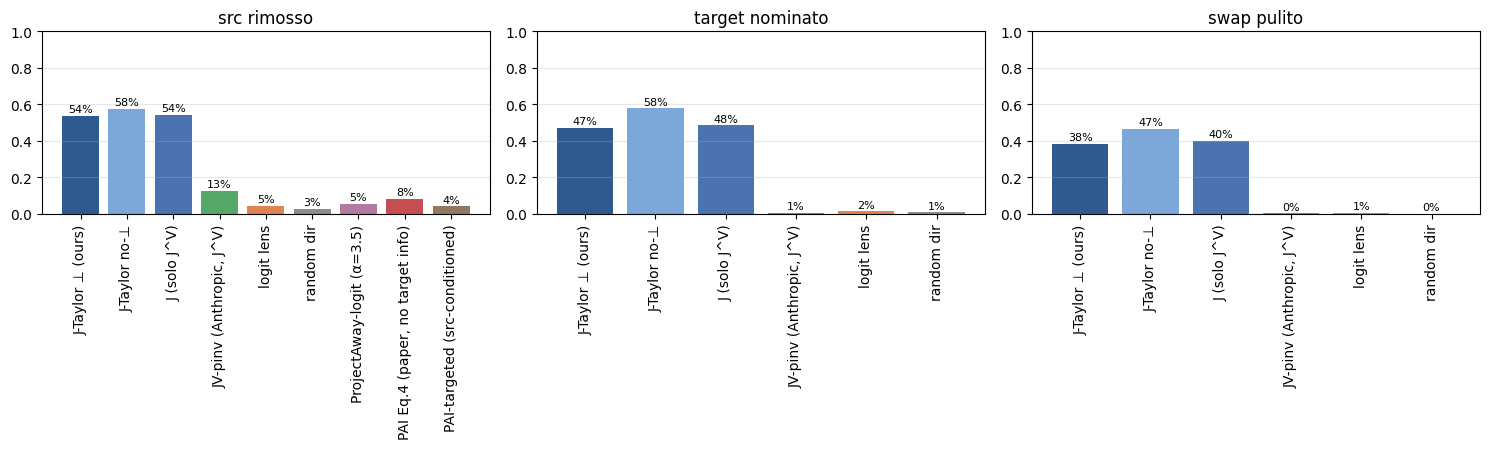

In [16]:
import os, json
import pandas as pd
import matplotlib.pyplot as plt

RESDIR = "./risultati_J_vs_baselines_llava_a1_ortho_JV_pinv_PAI_fair_plus_targeted_ProjectAway_logit/results"   # stesso path della run (CACHE/results)
FIGDIR = "./risultati_J_vs_baselines_llava_a1_ortho_JV_pinv_PAI_fair_plus_targeted_ProjectAway_logit/figs"

METHODS_ORDER = ["J-taylor", "J-taylor-raw", "J", "JV-pinv", "logit", "random",
                 "project_away", "pai", "pai_targeted"]

# Solo questi metodi ricevono esplicitamente anche `new_src` e implementano
# una vera operazione di sostituzione/innesto. ProjectAway e PAI sono baseline
# di sola rimozione, quindi non vanno mostrate nel pannello "swap pulito".
SWAP_METHODS = {"J-taylor", "J-taylor-raw", "J", "JV-pinv", "logit", "random"}
MLABEL = {"J-taylor": "J-Taylor \u22a5 (ours)", "J-taylor-raw": "J-Taylor no-\u22a5",
          "J": "J (solo J^V)", "JV-pinv": "JV-pinv (Anthropic, J^V)", "logit": "logit lens",
          "random": "random dir", "project_away": "ProjectAway-logit (α=3.5)",
          "pai": "PAI Eq.4 (paper, no target info)",
          "pai_targeted": "PAI-targeted (src-conditioned)"}
MCOLOR = {"J-taylor": "#2E5A8F", "J-taylor-raw": "#7BA7D9", "J": "#4C72B0",
          "JV-pinv": "#55A868", "logit": "#DD8452", "random": "#8C8C8C",
          "project_away": "#B07AA1", "pai": "#C44E52", "pai_targeted": "#937860"}

rows = []
for m in METHODS_ORDER:
    p = os.path.join(RESDIR, f"part1_{m}.json")
    if not os.path.exists(p):
        print(f"[{m}] nessun risultato trovato ({p})"); continue
    d = json.load(open(p)); recs = d.get("records", [])
    n = len(recs)
    if n == 0:
        print(f"[{m}] 0 record"); continue
    removed = sum(r["removed"] for r in recs) / n
    induced = sum(r["new_mentioned"] for r in recs) / n
    swap    = sum(r["swap"] for r in recs) / n
    rows.append(dict(metodo=m, label=MLABEL.get(m, m), n=n,
                     removed=removed, induced=induced, swap=swap))

if not rows:
    print("Nessun risultato su disco in", RESDIR, "- esegui prima la cella 1.2 (loop reliability).")
else:
    df = pd.DataFrame(rows).set_index("label")[["n", "removed", "induced", "swap"]]
    print(df.round(3).to_string())
    out_csv = os.path.join(RESDIR, "reliability_summary.csv")
    df.to_csv(out_csv); print("\nsalvato:", out_csv)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
    panels = [("removed", "src rimosso"), ("induced", "target nominato"), ("swap", "swap pulito")]

    for j, (key, title) in enumerate(panels):
        # Per rimozione e target nominato mostriamo tutte le baseline.
        # Per lo swap escludiamo i metodi di sola rimozione, per i quali
        # un'eventuale menzione del target sarebbe soltanto spontanea.
        if key == "swap":
            panel_rows = [r for r in rows if r["metodo"] in SWAP_METHODS]
        elif key == "induced":
            # `target nominato` ha senso solo per i metodi a cui viene fornito new_src.
            panel_rows = [r for r in rows if r["metodo"] in SWAP_METHODS]
        else:
            # `src rimosso`: include anche ProjectAway e PAI.
            panel_rows = rows

        labels = [r["label"] for r in panel_rows]
        vals = [r[key] for r in panel_rows]
        colors = [MCOLOR.get(r["metodo"], "#888") for r in panel_rows]

        ax[j].bar(labels, vals, color=colors)
        ax[j].set_ylim(0, 1)
        ax[j].set_title(title)
        ax[j].tick_params(axis="x", rotation=90)
        ax[j].grid(axis="y", alpha=.3)

        for i, v in enumerate(vals):
            ax[j].text(i, v + 0.02, f"{v:.0%}", ha="center", fontsize=8)
    plt.tight_layout()
    os.makedirs(FIGDIR, exist_ok=True)
    fig_path = os.path.join(FIGDIR, "fig_reliability.png")
    fig.savefig(fig_path, dpi=200, bbox_inches="tight")
    print("salvato:", fig_path)
    plt.show()


In [17]:
import os, json

RESDIR = "./risultati_J_vs_baselines_llava_a1_ortho_JV_pinv_PAI_fair_plus_targeted_ProjectAway_logit/results"

METHODS_ORDER = ["J-taylor", "J-taylor-raw", "J", "JV-pinv", "logit", "random",
                 "project_away", "pai", "pai_targeted"]
MLABEL = {"J-taylor": "J-Taylor \u22a5 (ours)", "J-taylor-raw": "J-Taylor no-\u22a5",
          "J": "J (solo J^V)", "JV-pinv": "JV-pinv (Anthropic, J^V)", "logit": "logit lens",
          "random": "random dir", "project_away": "ProjectAway-logit (α=3.5)",
          "pai": "PAI Eq.4 (paper, no target info)",
          "pai_targeted": "PAI-targeted (src-conditioned)"}

# ---- carica i trial condivisi (per la didascalia BASE e src/new_src) ----
trials_path = os.path.join(RESDIR, "trials_shared.json")
assert os.path.exists(trials_path), f"non trovato: {trials_path}"
TS = json.load(open(trials_path))
TRIALS = TS["trials"]            # lista di {img, src, new_src}, indice k = ordine del trial
BASE_CAPS = TS["base_caps"]      # indicizzata per numero immagine (tr["img"])

# ---- carica edited_desc per ogni metodo (allineati per indice k, stesso ordine dei TRIALS) ----
METHOD_RECORDS = {}
for m in METHODS_ORDER:
    p = os.path.join(RESDIR, f"part1_{m}.json")
    if not os.path.exists(p):
        print(f"[{m}] nessun risultato trovato ({p})"); continue
    d = json.load(open(p))
    METHOD_RECORDS[m] = d.get("records", [])

n_avail = min(len(v) for v in METHOD_RECORDS.values()) if METHOD_RECORDS else 0
print(f"trial totali: {len(TRIALS)} | trial completi (min tra i metodi): {n_avail}")

# =====================================================================================
# CONFIGURA QUI cosa vedere:
#   - N_SHOW: quanti trial mostrare
#   - SELECT: "first" | "swap_only_J" | "random"  (SELECT filtra quali trial mostrare)
#   - K_LIST: se vuoi indici precisi, mettili qui (sovrascrive SELECT), es. K_LIST=[0,5,12]
# =====================================================================================
N_SHOW = 8
SELECT = "first"      # cambia in "swap_only_J" per vedere solo i casi in cui J-taylor riesce
K_LIST = None

import random as _r
if K_LIST is not None:
    idxs = K_LIST
elif SELECT == "first":
    idxs = list(range(min(N_SHOW, n_avail)))
elif SELECT == "swap_only_J":
    ref = METHOD_RECORDS.get("J-taylor", [])
    idxs = [k for k, r in enumerate(ref) if r.get("swap")][:N_SHOW]
elif SELECT == "random":
    _r.seed(0)
    idxs = _r.sample(range(n_avail), min(N_SHOW, n_avail))
else:
    raise ValueError(SELECT)

for k in idxs:
    tr = TRIALS[k]
    base = BASE_CAPS[tr["img"]]
    print("=" * 100)
    print(f"trial #{k}  |  img={tr['img']}  |  src='{tr['src']}'  ->  new_src='{tr['new_src']}'")
    print("-" * 100)
    print(f"{'BASE':<20}: {base}")
    for m in METHODS_ORDER:
        recs = METHOD_RECORDS.get(m)
        if recs is None or k >= len(recs):
            continue
        r = recs[k]
        flag = []
        if r.get("removed"): flag.append("removed")
        if r.get("new_mentioned"): flag.append("induced")
        if r.get("swap"): flag.append("SWAP-OK")
        flagtxt = f" [{', '.join(flag)}]" if flag else ""
        print(f"{MLABEL.get(m, m):<20}: {r.get('edited_desc', '')}{flagtxt}")
    print()

trial totali: 332 | trial completi (min tra i metodi): 332
trial #0  |  img=0  |  src='chair'  ->  new_src='fork'
----------------------------------------------------------------------------------------------------
BASE                : In the image, you can see a dining table, chairs, a refrigerator, a television, a clock, a potted plant, and a vase. The dining
J-Taylor ⊥ (ours)   : In the image, you can see a kitchen with a dining table, a fork, a knife, a spoon, a bowl, a clock, a refrigerator, a [removed, induced, SWAP-OK]
J-Taylor no-⊥       : In the image, you can see a fork, a fork, a fork, a fork, a fork, a fork, a fork, a fork, a fork, a fork, a fork, [removed, induced, SWAP-OK]
J (solo J^V)        : In the image, you can see a kitchen with a dining table, a fork, a knife, a spoon, a bowl, a clock, a refrigerator, a [removed, induced, SWAP-OK]
JV-pinv (Anthropic, J^V): In the image, you can see a dining table, chairs, a refrigerator, a television, a potted plant, a vase, and a

metodo               | n succ |  sim succ (media) | n fail |  sim fail (media)
J-Taylor ⊥ (ours)    |    127 |             0.228 |    205 |             0.276
J-Taylor no-⊥        |    155 |             0.230 |    177 |             0.282
J (solo J^V)         |    133 |             0.227 |    199 |             0.278


/tmp/ipykernel_1853680/2882272791.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax[j].boxplot(vals, labels=[MLABEL.get(m, m) for m in J_METHODS], patch_artist=True)
/tmp/ipykernel_1853680/2882272791.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax[j].boxplot(vals, labels=[MLABEL.get(m, m) for m in J_METHODS], patch_artist=True)


salvato: ./risultati_J_vs_baselines_llava_a1_ortho_JV_pinv_PAI_fair_plus_targeted_ProjectAway_logit/figs/fig_similarity_swap_success.png


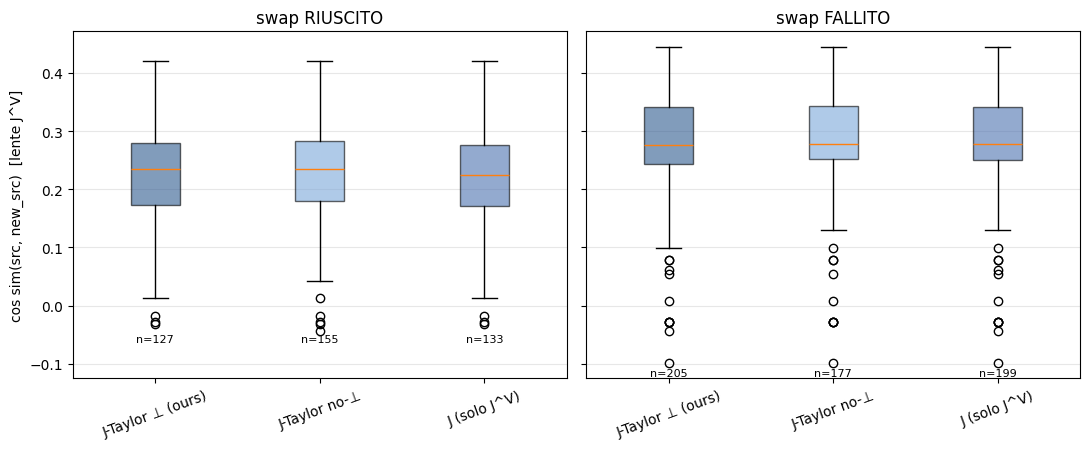

In [18]:
# 1.3 — Similarità coseno src<->new_src (lente J^V, media su EDIT_LAYERS) vs esito dello swap,
# per i 3 metodi J (J-taylor, J-taylor-raw, J). Richiede lenti+modello caricati (celle 0.1-0.4),
# NON serve rieseguire il loop di generazione: legge swap/src/new_src da part1_{method}.json.

import os, json
import numpy as np
import matplotlib.pyplot as plt

J_METHODS = ["J-taylor", "J-taylor-raw", "J"]

# similarità coseno src<->new_src nella lente J^V, media sui layer di editing.
# è una proprietà della COPPIA (src,new_src), non del metodo: stessa formula per tutti e 3.
def pair_similarity(src, new_src, layers=EDIT_LAYERS):
    sims = []
    for l in layers:
        v_s = concept_vec_cached(l, src, "V")
        v_t = concept_vec_cached(l, new_src, "V")
        cos = (v_s @ v_t) / (v_s.norm() * v_t.norm()).clamp_min(EPS)
        sims.append(cos.item())
    return float(np.mean(sims))

_pair_sim_cache = {}
def get_pair_sim(src, new_src):
    key = (src, new_src)
    if key not in _pair_sim_cache:
        _pair_sim_cache[key] = pair_similarity(src, new_src)
    return _pair_sim_cache[key]

# per ogni metodo: similarità dei trial con swap riuscito / fallito
sim_success = {m: [] for m in J_METHODS}
sim_fail    = {m: [] for m in J_METHODS}

for m in J_METHODS:
    p = os.path.join(RESDIR, f"part1_{m}.json")
    if not os.path.exists(p):
        print(f"[{m}] nessun risultato trovato ({p})"); continue
    recs = json.load(open(p))["records"]
    for r in recs:
        sim = get_pair_sim(r["src"], r["new_src"])
        (sim_success if r["swap"] else sim_fail)[m].append(sim)

# ---- report numerico ----
print(f"{'metodo':<20} | {'n succ':>6} | {'sim succ (media)':>17} | {'n fail':>6} | {'sim fail (media)':>17}")
for m in J_METHODS:
    ns, nf = len(sim_success[m]), len(sim_fail[m])
    ms = np.mean(sim_success[m]) if ns else float("nan")
    mf = np.mean(sim_fail[m]) if nf else float("nan")
    print(f"{MLABEL.get(m, m):<20} | {ns:>6} | {ms:>17.3f} | {nf:>6} | {mf:>17.3f}")

# ---- 2 boxplot: swap riuscito vs swap fallito, 3 box per metodo J ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)

for j, (data, title) in enumerate([(sim_success, "swap RIUSCITO"), (sim_fail, "swap FALLITO")]):
    vals = [data[m] for m in J_METHODS]
    colors = [MCOLOR.get(m, "#888") for m in J_METHODS]
    bp = ax[j].boxplot(vals, labels=[MLABEL.get(m, m) for m in J_METHODS], patch_artist=True)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(.6)
    ax[j].set_title(title)
    if j == 0:
        ax[j].set_ylabel("cos sim(src, new_src)  [lente J^V]")
    ax[j].tick_params(axis="x", rotation=20)
    ax[j].grid(axis="y", alpha=.3)
    ymin = ax[j].get_ylim()[0]
    for i, m in enumerate(J_METHODS):
        ax[j].text(i + 1, ymin, f"n={len(data[m])}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
os.makedirs(FIGDIR, exist_ok=True)
fig_path = os.path.join(FIGDIR, "fig_similarity_swap_success.png")
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
print("salvato:", fig_path)
plt.show()

In [ ]:
1